### General Gradient Descent

In [2]:
from sklearn.datasets import make_regression

In [3]:
X,Y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

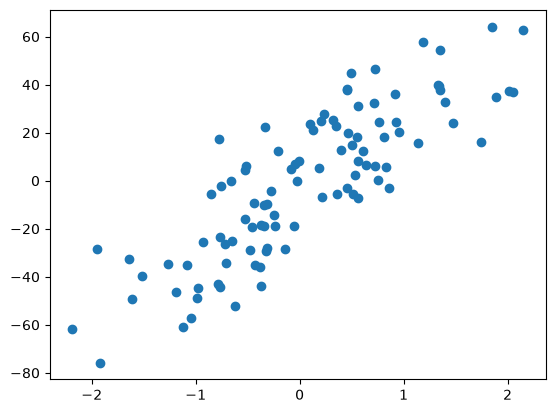

In [4]:
plt.scatter(X,Y)

In [21]:
lr = LinearRegression()
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[28.13]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.271
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[8.7]


In [22]:
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [23]:
Y_pred = lr.predict(X_test)

In [25]:
from sklearn.metrics import r2_score
r2_score(Y_test,Y_pred)

0.6345158782661012

In [7]:
np.mean(cross_val_score(lr,X,Y,scoring='r2',cv=10))

np.float64(0.6375011587464419)

In [14]:
class custom_gd:
    def __init__(self,rate,epochs):
        self.m = 100
        self.b = -120
        self.rate = rate
        self.epochs = epochs

    def fit(self,X,Y):
        for i in range(len(X)):
            loss_slope_b = -2 * np.sum(Y - self.m * X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((Y - self.m * X.ravel() - self.b) * X.ravel())
            
            self.b -= (self.rate * loss_slope_b)
            self.m -= (self.rate * loss_slope_m)
        print(self.m,self.b)

    def predict(self,X):
        return self.m * X + self.b

In [26]:
cgd = custom_gd(0.001,50)

In [27]:
cgd.fit(X_train,Y_train)

28.12627487585776 -2.2712395272648824


In [20]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [29]:
Y_pred_gd = cgd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(Y_test,Y_pred_gd)

0.6345146814256976

### Batch Gradient Descent

In [30]:
from sklearn.datasets import load_diabetes

In [32]:
X,Y = load_diabetes(return_X_y=True)

In [33]:
print(X.shape)
print(Y.shape)

(442, 10)
(442,)


In [34]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [35]:
lr = LinearRegression()
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -9.16,-205.45, 516.69,..., 126.73, 861.13, 52.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.79,1.1 ,0.98,...,0.58,0.24,0.08]"


In [36]:
print(lr.coef_)
print(lr.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [37]:
Y_pred = lr.predict(X_test)
r2_score(Y_test,Y_pred)

0.439933866156897

In [32]:
class custom_batch_gd:
    def __init__(self,learning_rate=0.01,epochs=100):
        self.coef_ = None
        self.intercept_ = None
        self.rate = learning_rate
        self.epochs = epochs
            
    def fit(self,X,Y):
        # initialise your coefs
        self.intercept_ = 0.0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            # update all the coefs and intercept
            # vectorization
            Y_hat = np.dot(X,self.coef_) + self.intercept_
            # print(Y_hat.shape)
            intercept_derivative = (-2) * np.mean(Y-Y_hat) 
            self.intercept_ -= (self.rate * intercept_derivative)
            coef_derivative = (-2) * np.dot((Y-Y_hat),X) / (X.shape[0])
            self.coef_ -= (self.rate * coef_derivative)
        print(self.intercept_,self.coef_)

    def predict(self,X):
        return np.dot(X,self.coef_) + self.intercept_
        

In [33]:
batch_gd = custom_batch_gd(0.01,100)

In [34]:
import time
start = time.time()
batch_gd.fit(X_train,Y_train)
print("Time Taken Is : ",time.time()-start)

130.52896930987225 [ 2.63772241  1.19060622  5.06046267  4.31375004  2.44715577  1.99246132
 -1.48838841  3.60218122  5.24193975  3.51394813]
Time Taken Is :  0.13318634033203125


In [83]:
Y_pred = batch_gd.predict(X_test)
r2_score(Y_test,Y_pred)

0.4534503034722803

### Stoichastic Gradient Descent

In [1]:
from sklearn.datasets import load_diabetes

In [2]:
X,Y = load_diabetes(return_X_y=True)

In [3]:
print(X.shape)
print(Y.shape)

(442, 10)
(442,)


In [4]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [5]:
lr = LinearRegression()
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -9.16,-205.45, 516.69,..., 126.73, 861.13, 52.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.79,1.1 ,0.98,...,0.58,0.24,0.08]"


In [6]:
print(lr.coef_)
print(lr.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [7]:
Y_pred = lr.predict(X_test)
r2_score(Y_test,Y_pred)

0.439933866156897

In [43]:
class custom_stoichastic_gd:
    def __init__(self,learning_rate=0.01,epochs=100):
        self.coef_ = None
        self.intercept_ = None
        self.rate = learning_rate
        self.epochs = epochs
        
    def fit(self,X,Y):
        self.intercept_ = 0.0
        self.coef_ = np.ones(X_train.shape[1])
        # learning schedules function
        # t0,t1 = 5,50
        # def learning_rate(t):
        #     return t0 / (t + t1)

        for i in range(self.epochs):
            for j in range(X.shape[0]):
                # rate = learning_rate(i*X.shape[0]+j) 
                idx = np.random.randint(0,X.shape[0])
                Y_hat = np.dot(X[idx],self.coef_) + self.intercept_
                intercept_derivative = (-2) * (Y[idx]-Y_hat)
                self.intercept_ -= (self.rate * intercept_derivative)
                coef_derivative = (-2) * np.dot((Y[idx]-Y_hat),X[idx])
                self.coef_ -= (self.rate * coef_derivative)

    def predict(self,X):
        return np.dot(X,self.coef_) + self.intercept_
        

In [44]:
stoichastic_gd = custom_stoichastic_gd(0.01,50)

In [45]:
start = time.time()
stoichastic_gd.fit(X_train,Y_train)
print("Time Taken Is : ",time.time()-start)

Time Taken Is :  0.4821786880493164


In [46]:
Y_pred = stoichastic_gd.predict(X_test)
r2_score(Y_test,Y_pred)

0.43042233460856816

In [48]:
from sklearn.linear_model import SGDRegressor

In [50]:
reg = SGDRegressor(max_iter=100,learning_rate='constant',eta0=0.01)

In [51]:
reg.fit(X_train,Y_train)

C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",100
,"learning_rate learning_rate: str, default='invscaling'The learning rate schedule:- 'constant': `eta = eta0`- 'optimal': `eta = 1.0 / (alpha * (t + t0))` where t0 is chosen by a heuristic proposed by Leon Bottou.- 'invscaling': `eta = eta0 / pow(t, power_t)`- 'adaptive': eta = eta0, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss by tol or fail to increase validation score by tol if early_stopping is True, the current learning rate is divided by 5.- 'pa1': passive-aggressive algorithm 1, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = min(eta0, loss/||x||**2)`.- 'pa2': passive-aggressive algorithm 2, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = hinge_loss / (||x||**2 + 1/(2 eta0))`... versionadded:: 0.20 Added 'adaptive' option... versionadded:: 1.8 Added options 'pa1' and 'pa2'",'constant'
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the

In [52]:
Y_pred = reg.predict(X_test)

In [53]:
r2_score(Y_test,Y_pred)

0.43254367994667897

### Mini-Batch Gradient Descent

In [1]:
from sklearn.datasets import load_diabetes

In [2]:
X,Y = load_diabetes(return_X_y=True)

In [3]:
print(X.shape)
print(Y.shape)

(442, 10)
(442,)


In [4]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [6]:
lr = LinearRegression()
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -9.16,-205.45, 516.69,..., 126.73, 861.13, 52.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.79,1.1 ,0.98,...,0.58,0.24,0.08]"


In [7]:
print(lr.coef_)
print(lr.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [8]:
Y_pred = lr.predict(X_test)
r2_score(Y_test,Y_pred)

0.439933866156897

In [20]:
import random
class custom_mini_batch_gd:
    def __init__(self,batch_size,learning_rate=0.01,epochs=100):
        self.coef_ = None
        self.intercept_ = None
        self.rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
            
    def fit(self,X,Y):
        # initialise your coefs
        self.intercept_ = 0.0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            for j in range(X.shape[0]//self.batch_size):
                idxs = random.sample(range(X.shape[0]),self.batch_size)
                Y_hat = np.dot(X[idxs],self.coef_) + self.intercept_
                intercept_derivative = (-2/self.batch_size) *np.sum(Y[idxs]-Y_hat) 
                self.intercept_ -= (self.rate * intercept_derivative)
                coef_derivative = (-2/self.batch_size) * np.dot((Y[idxs]-Y_hat),X[idxs])
                self.coef_ -= (self.rate * coef_derivative)
        print(self.intercept_,self.coef_)

    def predict(self,X):
        return np.dot(X,self.coef_) + self.intercept_
        

In [42]:
mini_batch_gd = custom_mini_batch_gd(batch_size=X_train.shape[0]//40,learning_rate=0.05,epochs=100)

In [43]:
mini_batch_gd.fit(X_train,Y_train)

153.2426561091932 [  47.89498008  -87.50011581  390.96611916  271.62334653    5.49305249
  -47.57436093 -180.03596359  124.22207347  353.6050586   128.41362489]


In [44]:
Y_pred = mini_batch_gd.predict(X_test)
r2_score(Y_test,Y_pred)

0.4422749179019585

In [46]:
from sklearn.linear_model import SGDRegressor
reg = SGDRegressor(learning_rate='constant',eta0=0.2)

In [47]:
batch_size = 35
for i in range(100):
    idxs = random.sample(range(X_train.shape[0]),batch_size)
    reg.partial_fit(X_train[idxs],Y_train[idxs])

In [48]:
reg.coef_

array([  34.23824394, -130.27716347,  464.74592245,  264.08664282,
        -34.96386052,  -94.31467138, -181.4118217 ,  110.17439153,
        364.55311216,  126.73969583])

In [49]:
reg.intercept_

array([142.6813114])

In [50]:
Y_pred = reg.predict(X_test)

In [51]:
r2_score(Y_test,Y_pred)

0.44044546834909815